### Import and Load Data

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

df = pd.read_csv('asan_extended_data.csv')
df.head()

,Wait Time (min),Appointment,Num Windows Visited,Staff Experience (yr),Time of Day,Liked Service
0,8,In-person,4,15,Afternoon,1
1,12,In-person,2,15,Morning,1
2,35,Online,3,5,Afternoon,0
3,30,Online,1,10,Afternoon,0
4,35,In-person,4,5,Afternoon,0


### Encode and Prepare

In [2]:
df_encoded = df.copy()
df_encoded['Appointment'] = (df_encoded['Appointment'] == 'In-person').astype(int)
df_encoded['Time of Day'] = (df_encoded['Time of Day'] == 'Morning').astype(int)

feature_cols = ['Wait Time (min)', 'Appointment', 'Num Windows Visited', 'Staff Experience (yr)', 'Time of Day']
X = df_encoded[feature_cols]
y = df_encoded['Liked Service']

### Training the model

In [8]:
tree = DecisionTreeClassifier(max_depth=20, min_samples_leaf=3, random_state=42)
tree.fit(X, y)

print(f"Depth: {tree.get_depth()}")
print(f"Leaves: {tree.get_n_leaves()}")
print(f"Training Accuracy: {tree.score(X, y):.3f}")

Depth: 8
Leaves: 36
Training Accuracy: 0.895


- Setting max_depth forces balanced trees

### Let's visualize

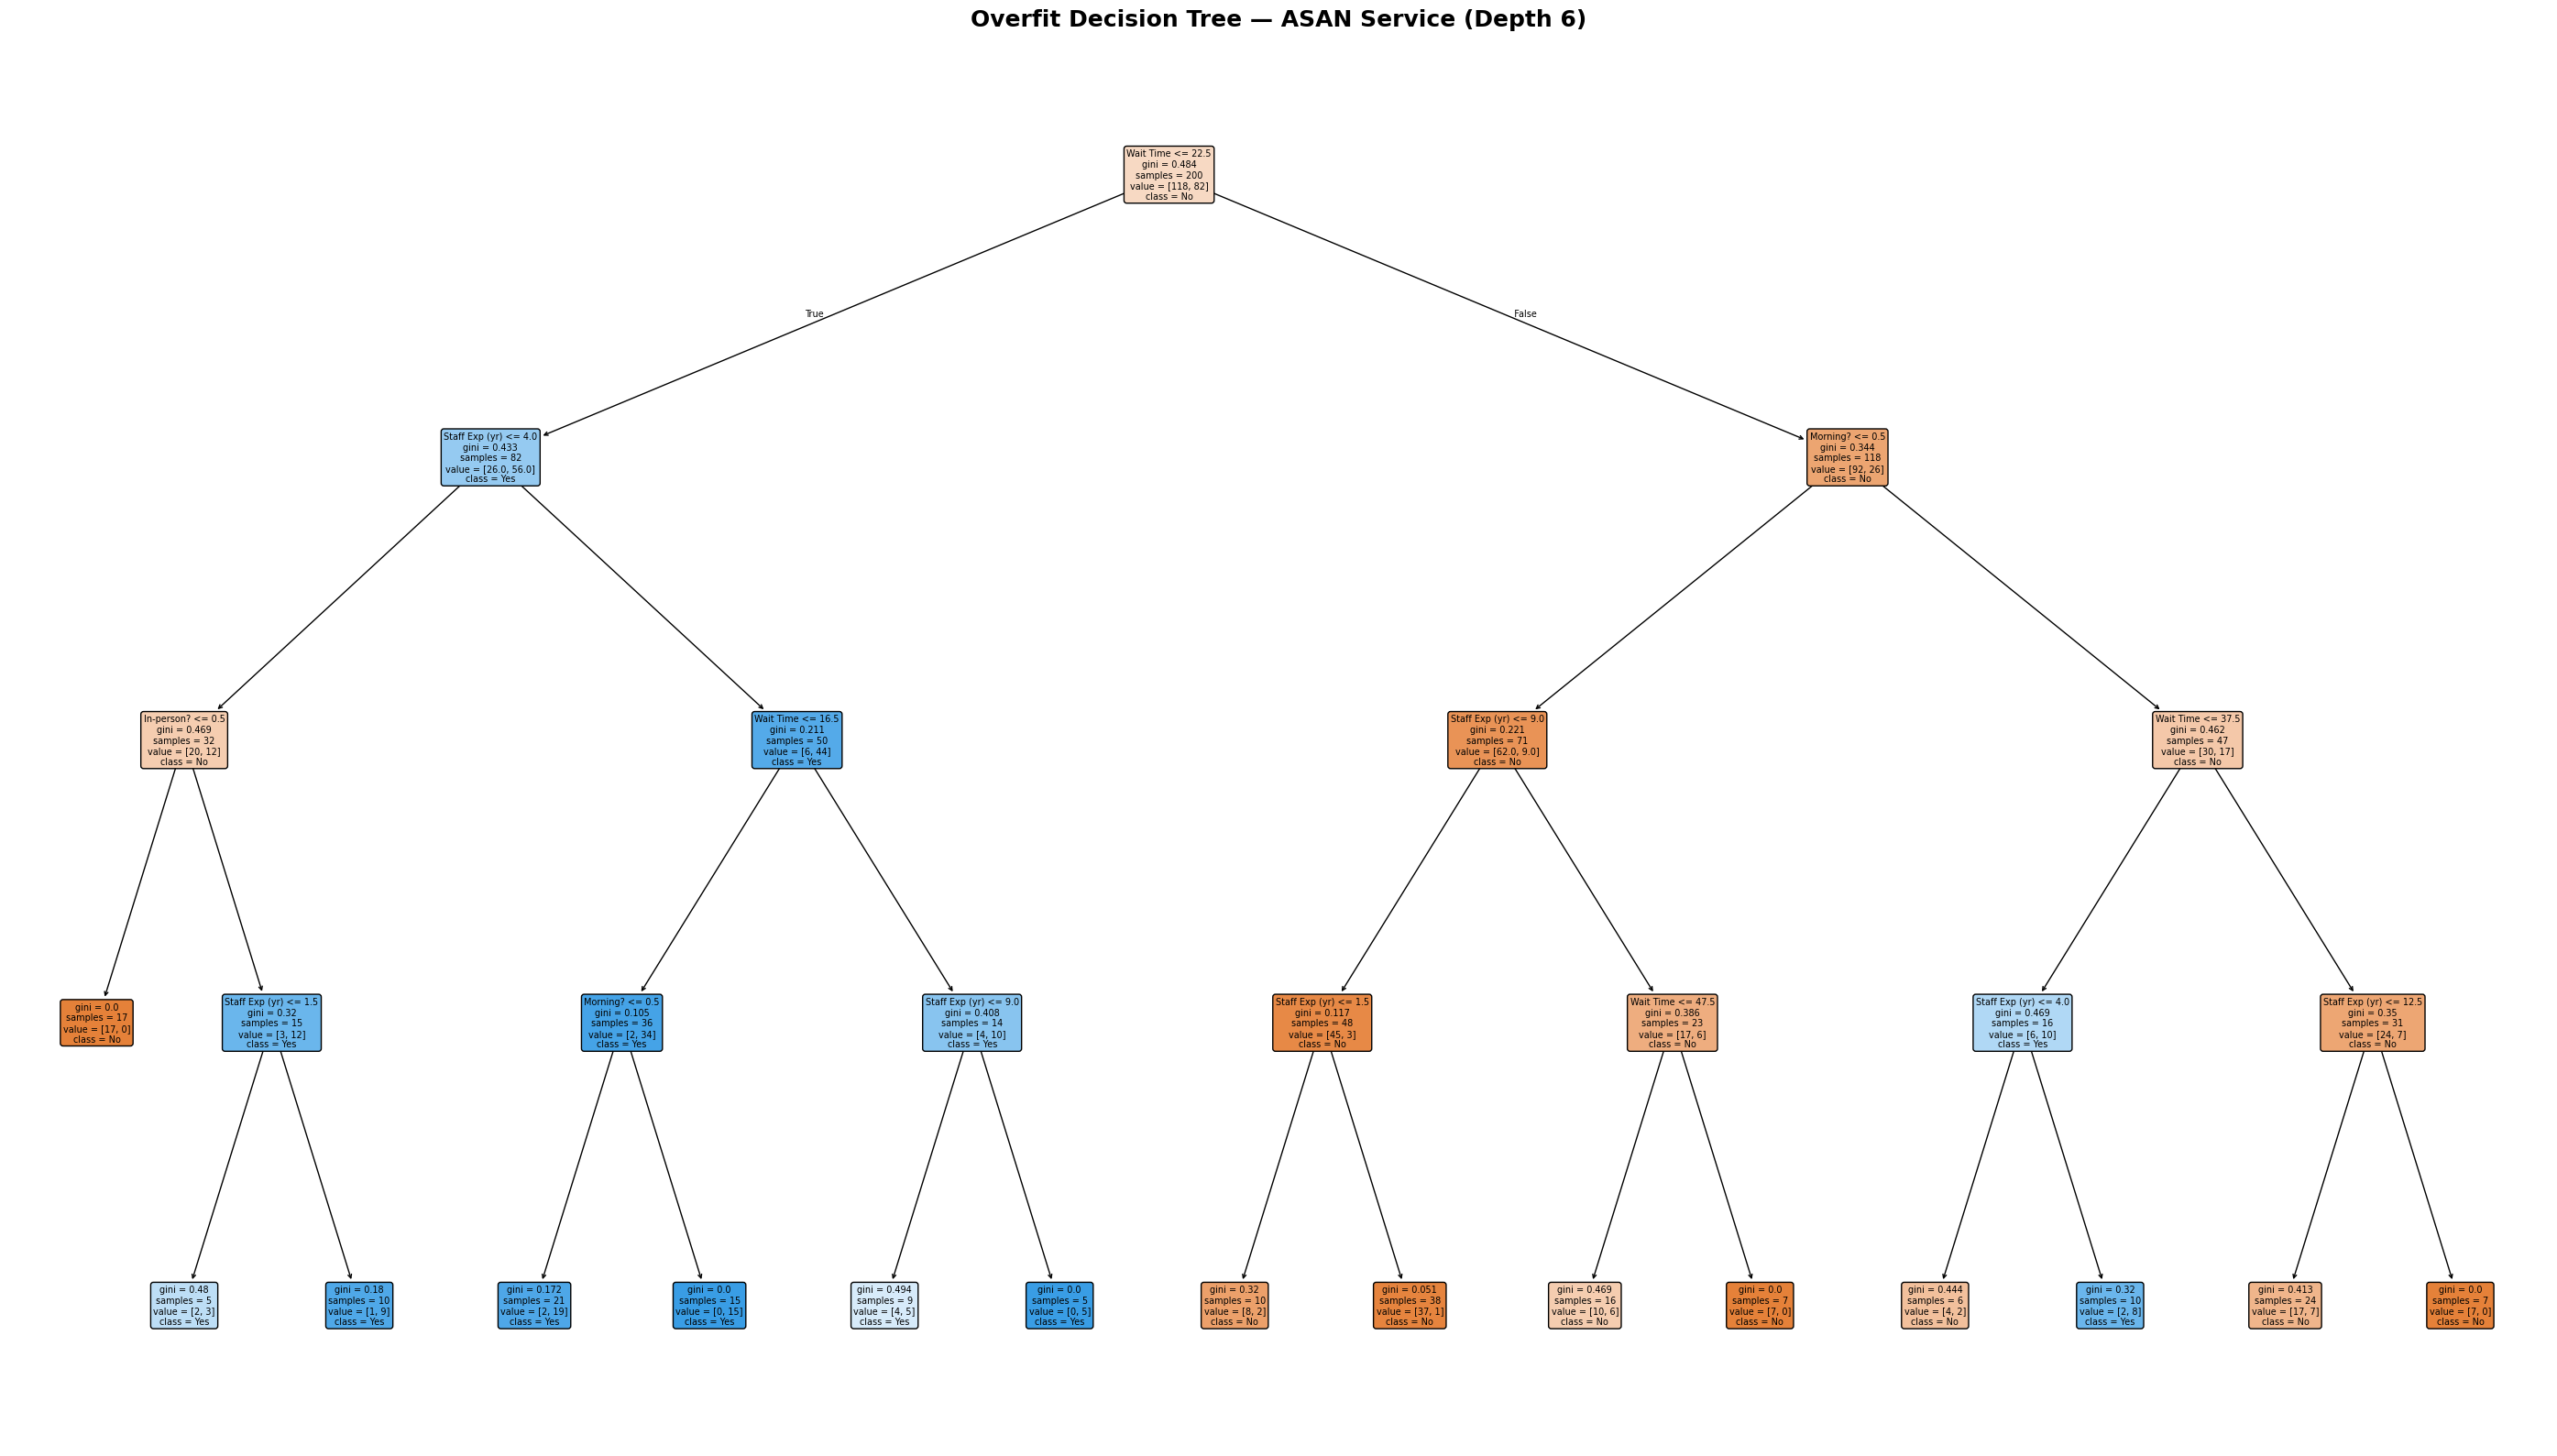

In [4]:
fig, ax = plt.subplots(figsize=(28, 16))
plot_tree(tree, 
          feature_names=['Wait Time', 'In-person?', 'Num Windows', 'Staff Exp (yr)', 'Morning?'],
          class_names=['No', 'Yes'],
          filled=True, rounded=True, fontsize=7,
          impurity=True, ax=ax)
ax.set_title('Overfit Decision Tree — ASAN Service (Depth 6)', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

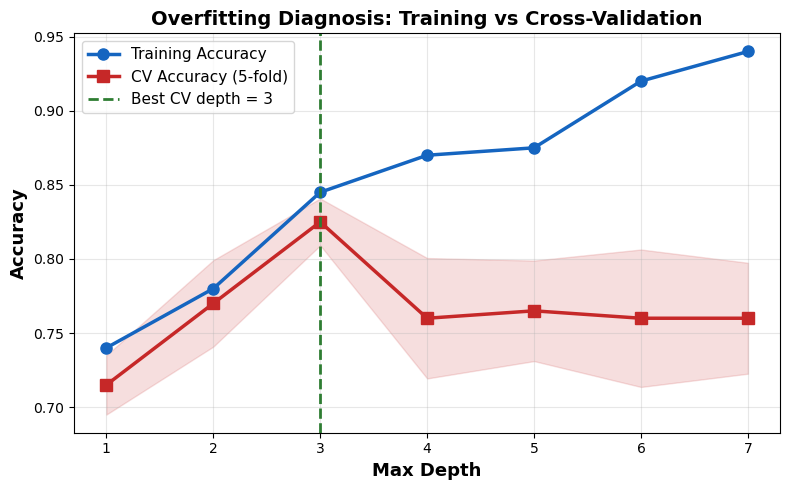

interactive(children=(IntSlider(value=3, description='Max Depth', max=7, min=1), Output()), _dom_classes=('wid…

<function __main__.interactive_prune(depth=3)>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('asan_extended_data.csv')
df_encoded = df.copy()
df_encoded['Appointment'] = (df_encoded['Appointment'] == 'In-person').astype(int)
df_encoded['Time of Day'] = (df_encoded['Time of Day'] == 'Morning').astype(int)

feature_cols = ['Wait Time (min)', 'Appointment', 'Num Windows Visited', 
                'Staff Experience (yr)', 'Time of Day']
feature_short = ['Wait Time', 'In-person?', 'Num Windows', 'Staff Exp (yr)', 'Morning?']
X = df_encoded[feature_cols].values
y = df_encoded['Liked Service'].values

# Find best depth by CV
cv_results = {}
for d in range(1, 8):
    cv = cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=42), X, y, cv=5)
    cv_results[d] = cv.mean()
best_depth = max(cv_results, key=cv_results.get)


# Cell 2: Train vs CV Accuracy Plot
depths = list(range(1, 8))
train_accs, cv_means, cv_stds = [], [], []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42)
    t.fit(X, y)
    train_accs.append(t.score(X, y))
    cv = cross_val_score(t, X, y, cv=5)
    cv_means.append(cv.mean())
    cv_stds.append(cv.std())

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depths, train_accs, 'o-', color='#1565c0', lw=2.5, markersize=8, label='Training Accuracy')
ax.plot(depths, cv_means, 's-', color='#c62828', lw=2.5, markersize=8, label='CV Accuracy (5-fold)')
ax.fill_between(depths,
                [m-s for m,s in zip(cv_means, cv_stds)],
                [m+s for m,s in zip(cv_means, cv_stds)],
                alpha=0.15, color='#c62828')
ax.axvline(best_depth, color='#2e7d32', ls='--', lw=2, label=f'Best CV depth = {best_depth}')
ax.set_xlabel('Max Depth', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax.set_title('Overfitting Diagnosis: Training vs Cross-Validation', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(depths)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Cell 3: Interactive Pruning Dashboard
def interactive_prune(depth=3):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X, y)
    cv = cross_val_score(tree, X, y, cv=5)
    
    fig, ax = plt.subplots(figsize=(22, 10))
    plot_tree(tree, feature_names=feature_short, class_names=['No', 'Yes'],
              filled=True, rounded=True, fontsize=8 if depth <= 4 else 6,
              impurity=True, ax=ax)
    
    is_best = depth == best_depth
    title = (f'Depth={depth} | Leaves={tree.get_n_leaves()} | '
             f'Train={tree.score(X,y):.3f} | CV={cv.mean():.3f} ± {cv.std():.3f}')
    if is_best:
        title += '  ★ BEST TREE ★'
    
    color = '#2e7d32' if is_best else '#c62828' if depth > best_depth else '#1565c0'
    ax.set_title(title, fontsize=15, fontweight='bold', color=color)
    plt.tight_layout()
    plt.show()

interact(interactive_prune, depth=IntSlider(min=1, max=7, step=1, value=best_depth, description='Max Depth'))